# EDA Bias Anotator - IndoToxic2024

Notebook ini menganalisis perilaku 19 anotator pada data mentah (43.692 anotasi,
satu baris = satu anotator menilai satu teks), dipadukan profil demografis
anotator dan metadata agreement hasil Step 3.

Urutan analisis:
1. profil demografi anotator
2. kecenderungan tiap anotator (siapa yang ketat, siapa yang longgar)
3. perbedaan penilaian antar kelompok anotator (identity_attack)
4. tingkat agreement antar anotator (pairwise + kappa)
5. agreement vs topik sensitif (pakai metadata agreement hasil Step 3)
6. kesimpulan: indikasi bias yang dicatat sebagai limitasi jurnal

Ganti variabel path di sel pertama sesuai komputer masing-masing.

In [1]:
# Yang perlu diganti hanya 3 baris di bawah ini.
# data: folder dataset mentah (2 file jsonl)
# file_agreement: file metadata agreement hasil step3
# folder_gambar: tempat nyimpan gambar

data = r'C:\SEMESTER 5\Project Sistem Cerdas\Projek\Dataset'
file_agreement = r'C:\SEMESTER 5\Project Sistem Cerdas\Projek\data\interim\agreement_metadata.jsonl'
folder_gambar = r'C:\SEMESTER 5\Project Sistem Cerdas\Projek\reports\figures'

# Kode di bawah tidak perlu diubah
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

if not os.path.isdir(data):
    raise FileNotFoundError('Folder dataset tidak ketemu: ' + data + '. Cek variabel data di atas.')

np.random.seed(42)
LABEL_COLS = ['toxicity', 'profanity_obscenity', 'threat_incitement_to_violence',
              'insults', 'identity_attack', 'sexually_explicit']
FIG_DIR = folder_gambar
os.makedirs(FIG_DIR, exist_ok=True)
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

def load_jsonl(p):
    with open(p, encoding='utf-8') as f:
        return [json.loads(l) for l in f if l.strip()]

raw = pd.DataFrame(load_jsonl(os.path.join(data, 'indotoxic2024_annotated_data-3.jsonl')))
profile = pd.DataFrame(load_jsonl(os.path.join(data, 'indotoxic2024_annotator_data.jsonl')))
raw['annotator_id'] = raw['annotator_id'].astype(int)
df = raw.merge(profile, on='annotator_id', how='left')

print('Baris anotasi :', len(df))
print('Anotator unik :', df.annotator_id.nunique())
df[['annotator_id', 'ethnicity', 'religion', 'gender', 'age', 'toxicity', 'identity_attack']].head(3)

Baris anotasi : 43692
Anotator unik : 19


,annotator_id,ethnicity,religion,gender,age,toxicity,identity_attack
0,20,Sunda,Islam,M,43,0,0
1,20,Sunda,Islam,M,43,0,0
2,20,Sunda,Islam,M,43,0,0


## 1. Profil demografi 19 anotator

Profil anotator tersedia di file indotoxic2024_annotator_data.jsonl: gender,
etnis, agama, usia, kota, pendidikan, dan status pekerjaan. Ini penting karena
persepsi hate speech dipengaruhi latar belakang si penilai, dan profil ini
menyediakan ID untuk membandingkan kelompok anotator.

Gender     : {'F': 12, 'M': 7}
Usia       : min 19, median 25, maks 50
Etnis      : {'Tionghoa': 3, 'Sunda': 2, 'Jawa': 2, 'Batak': 2, 'Minang': 2, 'Bugis': 2, 'Bali': 2, 'Melayu': 1, 'Dayak': 1, 'Madura': 1, 'Arab': 1}
Agama      : {'Islam': 9, 'Kristen': 2, 'Katolik': 2, 'Hindu': 2, 'Syiah': 1, 'Buddha': 1, 'Kepercayaan Lokal': 1, 'Ahmadiyah': 1}
Pendidikan : {'Sarjana (S1)': 7, 'Sekolah Menengah Atas (SMA)': 7, 'Magister (S2)': 3, 'Diploma': 2}
Status     : {'Bekerja': 9, 'Pelajar/Mahasiswa': 8, 'Ibu Rumah Tangga': 1, 'Tidak Bekerja': 1}


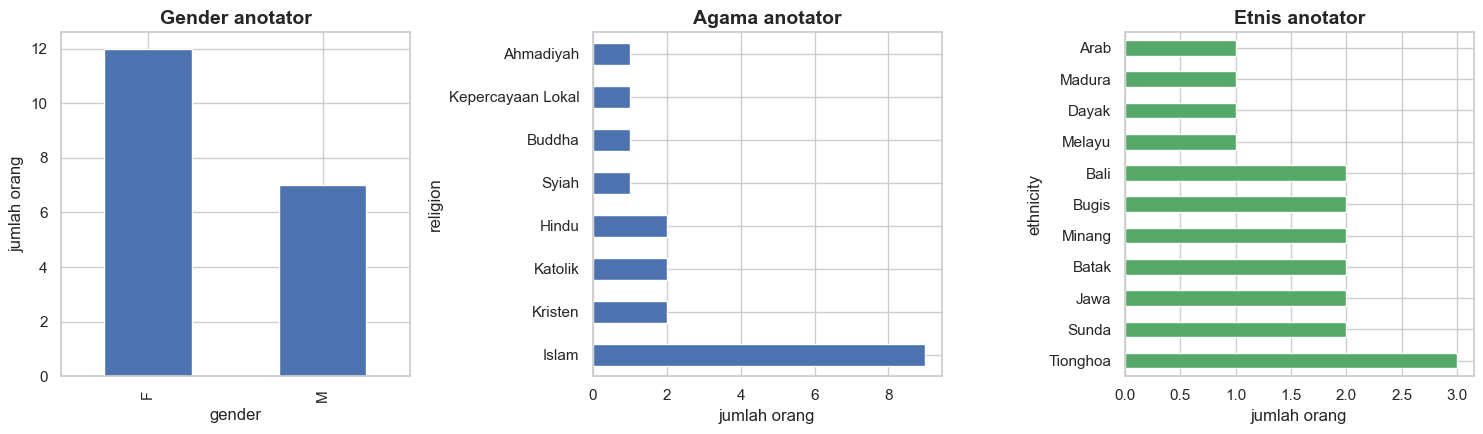

In [2]:
pro = df.drop_duplicates('annotator_id')
print('Gender     :', dict(pro.gender.value_counts()))
print('Usia       : min {}, median {}, maks {}'.format(pro.age.min(), int(pro.age.median()), pro.age.max()))
print('Etnis      :', dict(pro.ethnicity.value_counts()))
print('Agama      :', dict(pro.religion.value_counts()))
print('Pendidikan :', dict(pro.last_education_degree.value_counts()))
print('Status     :', dict(pro.job_status.value_counts()))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
pro.gender.value_counts().plot(kind='bar', ax=axes[0], color='#4c72b0')
axes[0].set_title('Gender anotator')
axes[0].set_ylabel('jumlah orang')
pro.religion.value_counts().plot(kind='barh', ax=axes[1], color='#4c72b0')
axes[1].set_title('Agama anotator')
axes[1].set_xlabel('jumlah orang')
pro.ethnicity.value_counts().plot(kind='barh', ax=axes[2], color='#55a868')
axes[2].set_title('Etnis anotator')
axes[2].set_xlabel('jumlah orang')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '16_profil_anotator.png'), dpi=150, bbox_inches='tight')
plt.show()

**Kesimpulan bagian 1 (bahan PPT):**

Anotatornya 19 orang - 12 perempuan, 7 laki-laki, usia 19 sampai 50 tahun -
dengan latar etnis yang beragam (Jawa, Batak, Tionghoa, Minang, dll) dan agama
bervariasi (Islam mayoritas, plus Kristen, Hindu, Buddha, Syiah, Ahmadiyah).
Poin PPT: keragaman ini disengaja oleh pembuat dataset, karena persepsi
hate speech memang dipengaruhi identitas - dan profil ini yang memungkinkan
analisis perbedaan antar kelompok di bagian berikutnya.

## 2. Kecenderungan tiap anotator

Rasio hasil menyanggah toxicity tiap anotator dibandingkan dengan tingkat
keseluruhan akan terlihat siapa yang sedikit meleleh dan siapa yang
lebih cenderung longgar jauh dari rata-rata. Ini juga menampilkan tingkat
beban kerja antar anotator.

Bebar teks yang dinilai tiap anotator: min 100, median 2449.0, maks 4679
Global tingkat toxic (all anotator): 15.8%


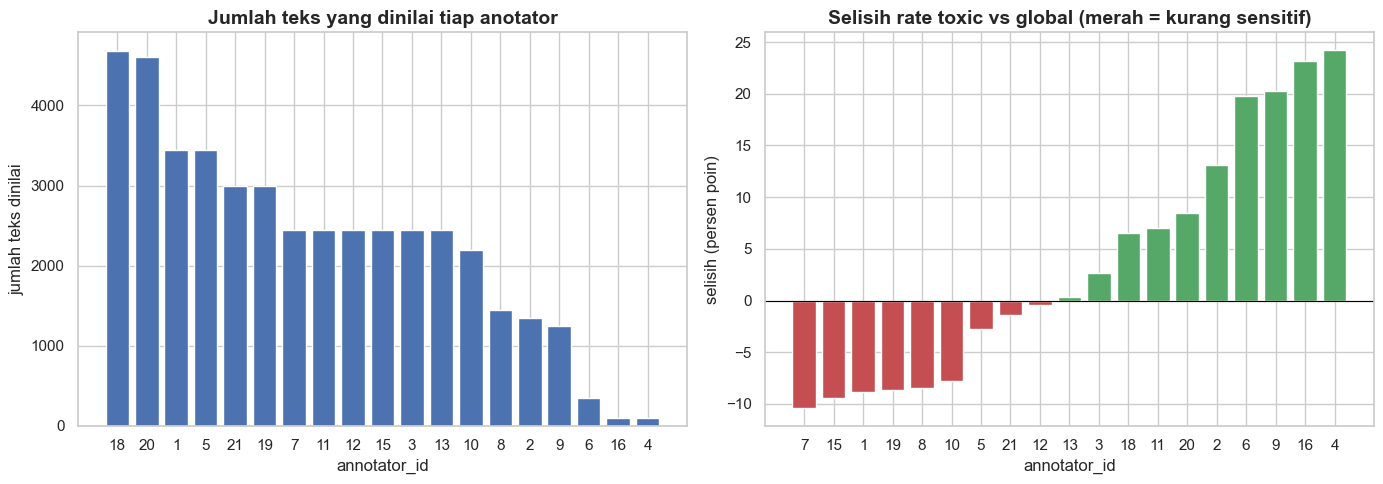

Anotator strict (deviasi -2 pp atau lebih): [7, 15, 1, 19, 8, 10, 5]
Anotator lenient (+2 pp atau lebih)       : [3, 18, 11, 20, 2, 6, 9, 16, 4]


In [3]:
trend = df.groupby('annotator_id')[LABEL_COLS].mean()
global_mean = df.toxicity.mean()
trend['dev_toxic_pp'] = (trend.toxicity - global_mean) * 100
trend = trend.sort_values('dev_toxic_pp')

act = df.groupby('annotator_id').agg(n_teks=('text_id', 'nunique')).sort_values('n_teks', ascending=False)
print('Bebar teks yang dinilai tiap anotator: min {}, median {}, maks {}'.format(
    act.n_teks.min(), act.n_teks.median(), act.n_teks.max()))
print('Global tingkat toxic (all anotator): {:.1%}'.format(global_mean))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(act.index.astype(str), act.n_teks, color='#4c72b0')
axes[0].set_title('Jumlah teks yang dinilai tiap anotator')
axes[0].set_xlabel('annotator_id')
axes[0].set_ylabel('jumlah teks dinilai')
warna = ['#c44e52' if v < 0 else '#55a868' for v in trend.dev_toxic_pp]
axes[1].bar(trend.index.astype(str), trend.dev_toxic_pp, color=warna)
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_title('Selisih rate toxic vs global (merah = kurang sensitif)')
axes[1].set_xlabel('annotator_id')
axes[1].set_ylabel('selisih (persen poin)')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '10_annotator_activity_tendency.png'), dpi=150, bbox_inches='tight')
plt.show()

strict_id = list(trend[trend.dev_toxic_pp < -2].index)
lenient_id = list(trend[trend.dev_toxic_pp > 2].index)
print('Anotator strict (deviasi -2 pp atau lebih):', strict_id)
print('Anotator lenient (+2 pp atau lebih)       :', lenient_id)

**Kesimpulan bagian 2 (bahan PPT):**

Ada variasi kecenderungan antar anotator: kelompok terpisah sebagai strict (jarang
manandai toxic) dan kelompok lain sebagai lenient (sering manandai toxic). Selain itu
beban kerja juga timpang - ada yang menilai ribuan teks, ada yang cuma ratusan.
Poin PPT: variasi penilaian seperti ini alami di anotasi manusia dan nanti bisa
berdampak ke keandalan label. Analisis keandalan itu lengkapnya dilakukan di
bagian 4 (agreement dan kappa).

## 3. Perbedaan penilaian antar kelompok anotator

Pertanyaan utama: apakah anotator dengan latar belakang tertentu menandai
identity_attack lebih sering dari kelompok lain? Ada dua cara membandingkan
yang kita tampilkan: (a) tanpa kontrol, yaitu semua teks yang dinilai oleh
masing-masing kelompok - tetapi kelompoknya menilai teks yang berbeda-beda,
jadi tidak adil; (b) dengan kontrol, hanya pada teks yang DINILAI KEDUA
kelompok, sehingga perbandingannya seimbang dan adil.

Anotator minoritas (bukan Islam): 10 orang
Anotator mayoritas (Islam)      : 9 orang

Perbandingan TANPA kontrol:
                               rate_min_%  rate_maj_%  selisih_pp
toxicity                             13.4        18.8        -5.4
profanity_obscenity                   2.6         3.5        -0.9
threat_incitement_to_violence         1.4         6.0        -4.6
insults                               7.5         7.2         0.2
identity_attack                       5.0        10.3        -5.3
sexually_explicit                     0.5         0.6        -0.1



Perbandingan DENGAN kontrol, 5235 teks sama:
                               rate_min_%  rate_maj_%  selisih_pp
toxicity                             25.0        25.9        -0.9
profanity_obscenity                   5.3         4.5         0.8
threat_incitement_to_violence         3.6         3.5         0.0
insults                              13.0        10.8         2.2
identity_attack                       8.7        15.6        -6.9
sexually_explicit                     1.2         1.1         0.1


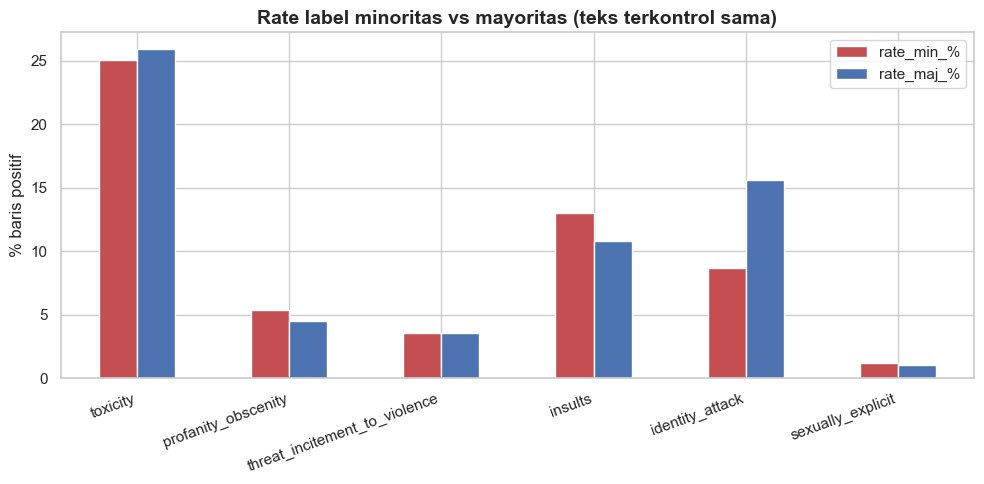

In [4]:
minor_ids = set(df.loc[df.religion != 'Islam', 'annotator_id'])
major_ids = set(df.annotator_id) - minor_ids

print('Anotator minoritas (bukan Islam):', len(minor_ids), 'orang')
print('Anotator mayoritas (Islam)      :', len(major_ids), 'orang')

# perbandingan tanpa kontrol
minor_rows = df[df.annotator_id.isin(minor_ids)]
major_rows = df[df.annotator_id.isin(major_ids)]

hasil = pd.DataFrame(index=LABEL_COLS)
hasil['rate_min_%'] = minor_rows[LABEL_COLS].mean() * 100
hasil['rate_maj_%'] = major_rows[LABEL_COLS].mean() * 100
hasil['selisih_pp'] = hasil['rate_min_%'] - hasil['rate_maj_%']
print()
print('Perbandingan TANPA kontrol:')
print(hasil.round(1).to_string())

# perbandingan dengan kontrol (teks yang sama dinilai kedua kelompok)
grup_teks = df.groupby('text_id')['annotator_id'].agg(set)
sama = [t for t, ids in grup_teks.items()
        if (ids & minor_ids) and (ids & major_ids)]
sub = df[df.text_id.isin(sama)]
sub_min = sub[sub.annotator_id.isin(minor_ids)]
sub_maj = sub[sub.annotator_id.isin(major_ids)]

hasil2 = pd.DataFrame(index=LABEL_COLS)
hasil2['rate_min_%'] = sub_min[LABEL_COLS].mean() * 100
hasil2['rate_maj_%'] = sub_maj[LABEL_COLS].mean() * 100
hasil2['selisih_pp'] = hasil2['rate_min_%'] - hasil2['rate_maj_%']
print()
print('Perbandingan DENGAN kontrol, {} teks sama:'.format(len(sama)))
print(hasil2.round(1).to_string())

hasil2[['rate_min_%', 'rate_maj_%']].plot(kind='bar', figsize=(10, 5),
                                          color=['#c44e52', '#4c72b0'])
plt.title('Rate label minoritas vs mayoritas (teks terkontrol sama)')
plt.ylabel('% baris positif')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '13_minority_vs_majority.png'), dpi=150, bbox_inches='tight')
plt.show()

**Kesimpulan bagian 3 (bahan PPT):**

Perhatikan kedua tabel. Angka tanpa kontrol mencampur perbedaan jenis teks dan
perbedaan sudut pandang pengamat, jadi tidak bisa langsung ditarik kesimpulan.
Angka dengan kontrol (teks yang sama dinilai dua kelompok) yang lebih layak
dipercaya: ada label yang perbedaannya jelas, terutama identity_attack dan
threat_incitement_to_violence. Karena anotatornya cuma 19 orang, ini dianggap
sebagai indikasi, bukan kesimpulan final.

## 4. Tingkat kesepakatan antar anotator

Teks dengan anotator banyak mungkin sulit dinilai. Jika anotator tidak sepakat
pada banyak teks, itu sinyal bahwa label datanya tidak pasti. Pairwise
agreement mengukur berapa persen pasangan anotator yang menilai sama, dan
kappa mengukur kesepakatan di luar kebetulan (semakin mendekati 1 semakin
kuat; 0.4-0.6 moderate, di bawah 0.4 lemah).

In [5]:
def fleiss_kappa(matriks):
    m = np.asarray(matriks, dtype=float)
    n_rater = m.sum(axis=1)
    if not ((n_rater == n_rater[0]).all() and n_rater[0] >= 2):
        return float('nan')
    p_i = ((m ** 2).sum(axis=1) - n_rater) / (n_rater * (n_rater - 1))
    P_bar = p_i.mean()
    p_j = m.sum(axis=0) / m.sum()
    P_e = (p_j ** 2).sum()
    return (P_bar - P_e) / (1 - P_e) if P_e < 1 else 1.0


def krippendorff_alpha_nominal(list_unit):
    unit = [u for u in list_unit if len(u) >= 2]
    if not unit:
        return float('nan')
    sama = 0
    total_pasangan = 0
    for u in unit:
        k = sum(u)
        sama += k * (k - 1) // 2 + (len(u) - k) * (len(u) - k - 1) // 2
        total_pasangan += len(u) * (len(u) - 1) // 2
    D_o = 1 - sama / total_pasangan
    semua_angka = [v for u in unit for v in u]
    n_pos, n_tot = sum(semua_angka), len(semua_angka)
    D_e = 1 - (n_pos * (n_pos - 1) + (n_tot - n_pos) * (n_tot - n_pos - 1)) / (n_tot * (n_tot - 1))
    return 1 - D_o / D_e if D_e > 0 else 1.0


by_text = defaultdict(list)
for r in df[['text_id', 'annotator_id'] + LABEL_COLS].itertuples(index=False):
    by_text[r.text_id].append(r)

pair_stats = defaultdict(lambda: [0, 0])
for rows in by_text.values():
    if len(rows) < 2:
        continue
    for i in range(len(rows)):
        for j in range(i + 1, len(rows)):
            for c in LABEL_COLS:
                pair_stats[c][1] += 1
                pair_stats[c][0] += int(getattr(rows[i], c) == getattr(rows[j], c))

print('Pairwise agreement per label (pasangan anotator di teks sama):')
for c in LABEL_COLS:
    print('  {:32s} {:.1%}'.format(c, pair_stats[c][0] / pair_stats[c][1]))

n2 = [rows for rows in by_text.values() if len(rows) == 2]
print()
print('Fleiss kappa di stratum dengan 2 anotasi per teks ({} teks):'.format(len(n2)))
for c in LABEL_COLS:
    matriks = [[sum(getattr(r, c) for r in rows),
                len(rows) - sum(getattr(r, c) for r in rows)] for rows in n2]
    kap = fleiss_kappa(matriks)
    print('  {:32s} kappa = {:.3f}'.format(c, kap))

print()
print('Krippendorff alpha (semua teks >=2 anotasi, n bervariasi):')
for c in LABEL_COLS:
    a = krippendorff_alpha_nominal([[getattr(r, c) for r in rows] for rows in by_text.values() if len(rows) >= 2])
    print('  {:32s} alpha = {:.3f}'.format(c, a))

Pairwise agreement per label (pasangan anotator di teks sama):
  toxicity                         74.4%
  profanity_obscenity              93.3%
  threat_incitement_to_violence    88.2%
  insults                          85.2%
  identity_attack                  83.0%
  sexually_explicit                98.9%

Fleiss kappa di stratum dengan 2 anotasi per teks (9864 teks):
  toxicity                         kappa = 0.369
  profanity_obscenity              kappa = 0.251
  threat_incitement_to_violence    kappa = 0.003
  insults                          kappa = 0.235
  identity_attack                  kappa = 0.244
  sexually_explicit                kappa = 0.434

Krippendorff alpha (semua teks >=2 anotasi, n bervariasi):
  toxicity                         alpha = 0.252
  profanity_obscenity              alpha = 0.133
  threat_incitement_to_violence    alpha = -0.131
  insults                          alpha = 0.214
  identity_attack                  alpha = 0.059
  sexually_explicit        

**Kesimpulan bagian 4 (bahan PPT):**

Agreement antar anotator untuk toxicity hanya sekitar 74 persen, dan kappa
di area 0,3-0,4 (lemah sampai moderate). Ini artinya label dari manusia
tidak sepenuhnya konsisten - ada ambiguitas bawaan dalam mendefinisikan
hate speech. Dampaknya untuk proyek: model yang F1-nya mendekati tingkat
kesepakatan manusia sudah mencapai batas wajar, dan teks dengan penilaian
campuran layak ditinjau ulang secara khusus di analisis kesalahan.

## 5. Agreement vs topik sensitif

Pakai metadata agreement hasil step 3: tiap teks menyimpan proporsi anotator
yang menilai toxic (agreement_toxicity). Pertanyaannya: apakah teks dengan
topik SARA punya pola penilaian yang berbeda dibanding topik netral?
Analisis dibatasi ke teks beranotator >= 2, karena teks 1 anotator otomatis
punya agreement 0 atau 1 tanpa bisa dilihat sebagai "kesepakatan".

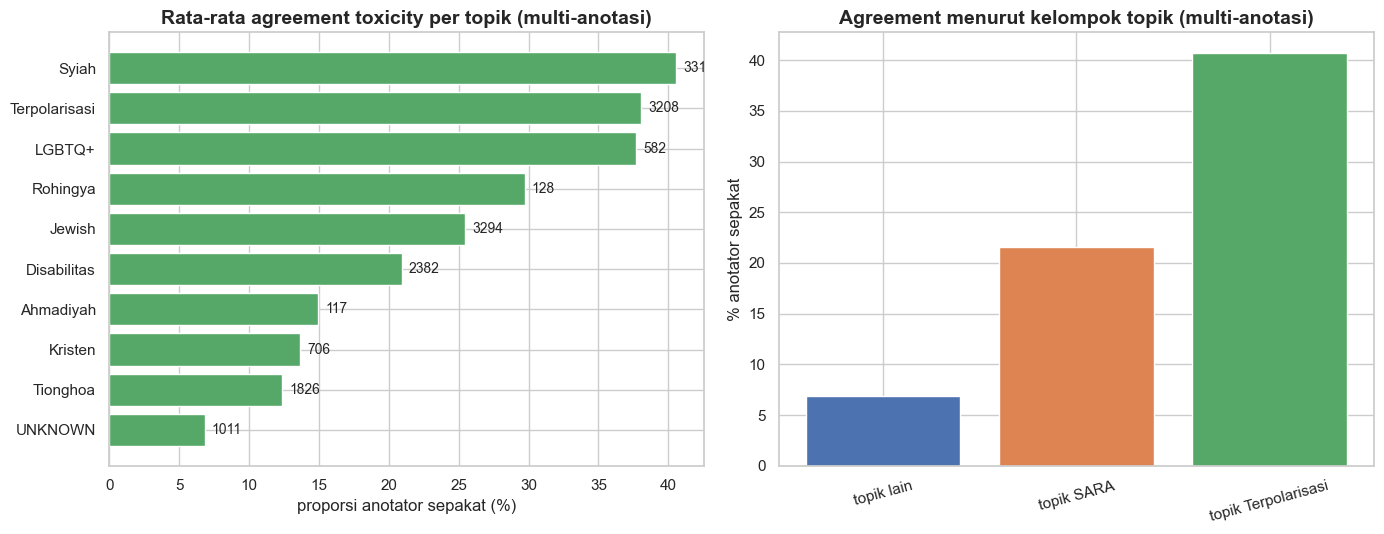

Agreement per topik (n>=50):
tlist
UNKNOWN           6.8
Tionghoa         12.4
Kristen          13.7
Ahmadiyah        15.0
Disabilitas      20.9
Jewish           25.5
Rohingya         29.7
LGBTQ+           37.7
Terpolarisasi    38.1
Syiah            40.6

Agreement per kategori topik:
                     mean  size
kategori                       
topik lain            6.8  1011
topik SARA           21.5  8946
topik Terpolarisasi  40.7   322


In [6]:
agr_step3 = pd.DataFrame(load_jsonl(file_agreement))
multi = agr_step3[agr_step3.n_annotators >= 2].copy()
multi['tlist'] = multi.topic.str.split(', ')
d2 = multi.explode('tlist')
d2['tlist'] = d2['tlist'].str.strip()
g = d2.groupby('tlist')['agreement_toxicity'].agg(['mean', 'size'])
g = g[g['size'] >= 50].sort_values('mean')

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
axes[0].barh(g.index, g['mean'] * 100, color='#55a868')
axes[0].set_title('Rata-rata agreement toxicity per topik (multi-anotasi)')
axes[0].set_xlabel('proporsi anotator sepakat (%)')
for i, (nama, row) in enumerate(g.iterrows()):
    axes[0].text(row['mean'] * 100 + 0.5, i, str(int(row['size'])),
                 va='center', fontsize=10)
sara_keys = ['Jewish', 'Syiah', 'Ahmadiyah', 'LGBTQ+', 'Rohingya',
             'Tionghoa', 'Kristen', 'Disabilitas']


def kategori(topik):
    daftar = set(topik.split(', '))
    yang_sara = [k for k in daftar if k in sara_keys]
    if yang_sara:
        return 'topik SARA'
    if 'Terpolarisasi' in daftar:
        return 'topik Terpolarisasi'
    return 'topik lain'


multi['kategori'] = multi.topic.apply(kategori)
gb = multi.groupby('kategori')['agreement_toxicity'].agg(['mean', 'size']).sort_values('mean')
axes[1].bar(gb.index, gb['mean'] * 100, color=sns.color_palette('deep', len(gb)))
axes[1].set_title('Agreement menurut kelompok topik (multi-anotasi)')
axes[1].set_ylabel('% anotator sepakat')
axes[1].tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '15_agreement_per_topik.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Agreement per topik (n>=50):')
hasil = g.assign(n_teks=g['size'].astype(int)).drop(columns='size')
print((hasil['mean'] * 100).round(1).to_string())
print()
print('Agreement per kategori topik:')
print((gb[['mean']] * 100).round(1).join(gb['size'].astype(int)).to_string())

**Kesimpulan bagian 5 (bahan PPT):**

Perhatikan panjang bar di kedua grafik. Pada teks multi-anotasi, proporsi
anotator yang bilang toxic paling tinggi bertopik Syiah (sekitar 40,6%) dan
Terpolarisasi (sekitar 38,1%), disusul LGBTQ+ (37,7%); paling rendah bertopik
UNKNOWN (6,8%) dan Tionghoa (12,4%). Artinya teks bertopik politik dan
SARA tertentu memang lebih sering diberi label toxic oleh anotator, sementara
topik lain relatif jarang. Pola ini menyayakan bahwa penilaian manusia
dipengaruhi muatan topik teks, dan pola ini nanti dianalisis lebih lanjut
saat error analysis model.

## Kesimpulan EDA Bias Anotator (bahan PPT)

- Ada variasi kecenderungan antar anotator (ada yang strict, ada yang longgar), ditambah dengan beban kerja yang timpang
- Agreement antar anotator rendah: pairwise toxicity ~74%, kappa ~0.37 (lemah sampai moderate)
- Pada teks yang sama, kelompok anotator mempunyai preferensi berbeda terutama pada label identity_attack dan threat
- Teks topik-SARA cenderung punya agreement lebih rendah dibanding topik lepas, sesuai dugaan bahwa ambiguitas naik seiring sensitivitas topik
- Semua gaya anotasi dipakai untuk menjelaskan limitasi di laporan jurnal: label manusia tidak sempurna dan tie-break safety-first di Step 3 adalah keputusan yang disengaja untuk mengurangi false negative

Batasan yang perlu dinyatakan di laporan:
1. Anotator hanya 19 orang, indikasi bias bersifat indikatif bukan konklusif
2. Kappa kecil mengingat definisi hate speech subjektif, bukan bukti kualitas anotator buruk
3. Agreement multi-anotator hanya ada pada sebagian teks (10.410 dari 28.449)

Semua gambar untuk PPT tersimpan di reports/figures/.